<b><font size="6"> Data Mining Project - Group 40 2025/2026 </font></b><br><br>
<i> <font size="4"> Amazing International Airlines Inc. (AIAI)</font></i>

`Group 40`

20250380 Maria Fonseca <br>
20250405 Ana Macedo <br>
20250453 Lourenço Silva <br>

### <font color='#BFD72F'>**Methodology** </font> <a class="anchor" id='toc'></a> 


- [1. Import libraries](#1) 
- [2. Loading the Data](#2) 
- [3. Metadata](#3)
- [4. Business Understanding](#4)
- [5. Data Preprocessing](#6)
    - [5.1. Duplicates](#6_1)
    - [5.2. Incoherences](#6_2)
    - [5.3. Missing Values](#6_3)
    - [5.4. Outliers](#6_4)

- [7. Feature Engineering](#7)
    - [7.1 FlightsDB](#7_1)
        - [7.1.1 Selecting Created Features](#7_1_1)
    - [7.2 CustomerDB](#7_2)
        - [7.2.1 Selecting Created Features](#7_2_1)
    - [7.3 Feature Engineering with Merged Datasets](#7_3)
        - [7.3.1 Merge Datasets](#7_3_1)
        - [7.3.2 Add Features](#7_3_2)
        - [7.3.3 Select Created Features](#7_3_3)
    - [7.4 Summary of Engineered Features](#7_4)





<a class="anchor" id="1">

# **1. Import libraries**

[Back to TOC](#toc)
</a>

In [82]:
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

# Import the create_boxplots function 
from functions import *

# for better resolution plots
%config InlineBackend.figure_format = 'retina'

np.random.seed(40311)
sns.set()

<a class="anchor" id="2">

# **2. Loading the Data**

[Back to TOC](#toc)
</a>

In [83]:
flightsDB = pd.read_csv('../../data/DM_AIAI_FlightsDB.csv', sep = ",")
customerDB = pd.read_csv('../../data/DM_AIAI_CustomerDB.csv', sep = ",")
metaData = pd.read_csv('../../data/DM_AIAI_Metadata.csv', sep = ";", header= None)

Remove the 'Unnamed' column referring to a sequential numbering of the rows, as we set the column "Loyalty#" as the index

In [84]:
customerDB = customerDB.iloc[:, 1:]
customerDB

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16916,100012,Ethan,Thompson,Ethan Thompson,Canada,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,NaN,Single,Star,2/27/2019,2/27/2019,NaN,Standard
16917,100013,Layla,Young,Layla Young,Canada,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,NaN,Married,Star,9/20/2017,9/20/2017,NaN,Standard
16918,100014,Amelia,Bennett,Amelia Bennett,Canada,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,NaN,Married,Star,11/28/2020,11/28/2020,NaN,Standard
16919,100015,Benjamin,Wilson,Benjamin Wilson,Canada,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,NaN,Married,Star,4/9/2020,4/9/2020,NaN,Standard


<a class="anchor" id="3">

# **3. Metadata**

[Back to TOC](#toc)
</a>

**FlightsDB Database feature Description**
- **Loyalty#:**	Unique customer identifier linking to CustomerDB
- **Year:**	Year of flight activity record
- **Month:**	Month of flight activity record (1-12)
- **YearMonthDate:**	First day of the month for the activity period
- **NumFlights:**	Total number of flights taken by customer in the month
- **NumFlightsWithCompanions:**	Number of flights where customer traveled with companions
- **DistanceKM:**	Total distance traveled in kilometers for the month
- **PointsAccumulated:**	Loyalty points earned by customer during the month
- **PointsRedeemed:**	Loyalty points spent/redeemed by customer during the month
- **DollarCostPointsRedeemed:**	Dollar value of points redeemed during the month

**CustomerDB Database feature Description**
- **Loyalty#:**  Unique customer identifier for loyalty program members
- **First Name:**   Customer's first name
- **Last Name:**   Customer's last name 
- **Customer Name:** Customer's full name (concatenated)
- **Country:**	Customer's country of residence
- **Province or State:**	Customer's province or state
- **City:**	Customer's city of residence
- **Latitude:**	Geographic latitude coordinate of customer location
- **Longitude:**	Geographic longitude coordinate of customer locatio
- **Postal code:**	Customer's postal/ZIP code
- **Gender:**	Customer's gender
- **Education:**	Customer's highest education level (Bachelor, College, etc.)
- **Location:** Code	Urban/Suburban/Rural classification of customer residence
- **Income:**	Customer's annual income
- **Marital Status:**	Customer's marital status (Married, Single, Divorced)
- **LoyaltyStatus:**	Current tier status in loyalty program (Star > Nova > Aurora)
- **EnrollmentDateOpening:**	Date when customer joined the loyalty program
- **CancellationDate:**	Date when customer left the program
- **Customer Lifetime:** Value	Total calculated monetary value of customer relationship
- **EnrollmentType:**	Method of joining loyalty program

<a class="anchor" id="4">

# **4. Business Understanding**

[Back to TOC](#toc)
</a>

Amazing International Airlines Inc. (AIAI) operates in a highly competitive industry, where customer retention and loyalty are essential for profitability. 

The company has a loyalty program but lacks personalization and individualized engagement strategies, limiting its ability to achieve high levels of customer satisfaction. As a result, marketing campaigns and rewards are often generic, reducing the effectiveness of loyalty initiatives. 

The company’s main challenge is to reduce customer churn and optimize the performance of its loyalty program. Without detailed insights into the different customer profiles, it becomes difficult to offer personalized services and targeted offers that enhance satisfaction and engagement. 

The main goal is to implement a data-driven approach to segment AIAI’s customers, identifying distinct groups based on behavioral, demographic, and value-related factors. This segmentation will allow the company to create personalized marketing strategies, develop targeted loyalty offers, and ultimately reduce customer churn by 5%, which corresponds to approximately €50,000 in monthly savings. To support these business goals, the project will aim to develop a clustering model capable of distinguishing customer profiles, create customer segments and ensure the model is scalable and adaptable to evolving customer behavior.

 The project will follow five main stages, aligned with the CRISP-DM methodology. 
 It will begin with an exploratory data analysis (EDA) to understand the available data, assess its quality, and identify potential issues such as missing values or outliers. 
 The second stage will involve data preprocessing, including cleaning, normalization, and transformation to prepare the dataset for clustering. 
 Next, clustering techniques will be applied to identify distinct customer groups based on behavioral, demographic, and value-related factors. 
 The fourth stage will focus on evaluating the model’s performance and interpreting the resulting segments to extract actionable marketing insights. Finally, the model will be deployed and continuously monitored to ensure scalability and adaptability as customer behavior evolves.

<a class="anchor" id="5">

# **5. Data Preprocessing**

[Back to TOC](#toc)
</a>

<a class="anchor" id="5_1">

## **5.1.** Duplicates

[Back to TOC](#toc)
</a>

In [85]:
flightsDB[flightsDB.duplicated(keep=False)]
#This code will display the duplicated rows in the flight dataset which are 5778 rows in Total

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
450,727091,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
535,369638,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
762,750578,2020,6,6/1/2020,0.0,0.0,0.0,0.0,0.0,0.0
941,547522,2020,6,6/1/2020,0.0,0.0,0.0,0.0,0.0,0.0
952,819842,2020,6,6/1/2020,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
607696,960050,2019,12,12/1/2019,0.0,0.0,0.0,0.0,0.0,0.0
608110,981508,2019,12,12/1/2019,0.0,0.0,0.0,0.0,0.0,0.0
608111,981508,2019,12,12/1/2019,0.0,0.0,0.0,0.0,0.0,0.0
608263,990512,2019,12,12/1/2019,0.0,0.0,0.0,0.0,0.0,0.0


In [86]:
customerDB[customerDB.duplicated(keep=False)]
#This code will display the duplicated rows in the customer dataset which are 0 rows in Total

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType


In [87]:
flightsDB.drop_duplicates(inplace=True)
customerDB.drop_duplicates(inplace=True)

In [88]:
flightsDB.set_index('Loyalty#', inplace=True)
customerDB.set_index('Loyalty#', inplace=True)

<a class="anchor" id="5_2">

## **5.2.** Incoherences

[Back to TOC](#toc)
</a>

<a class="anchor" id="5_2_1">

## **5.2.1.** Number of Flights as floats

[Back to TOC](#toc)
</a>

In [89]:
flightsDB["NumFlights"] = flightsDB["NumFlights"].astype(int)
flightsDB["NumFlightsWithCompanions"] = flightsDB["NumFlightsWithCompanions"].astype(int)

In [90]:
total_accumulated = flightsDB.groupby('Loyalty#')['PointsAccumulated'].sum()
#val1[:-1]

total_redeemed = flightsDB.groupby('Loyalty#')['PointsRedeemed'].sum()
#val2[:-1]

#inconsitency in 458 observations
(total_redeemed > total_accumulated).sum()

np.int64(458)

<a class="anchor" id="5_3">

## **5.3.** Missing Values

[Back to TOC](#toc)
</a>

From what we've seen before we have:
- 0 missing values in the flights data set

- 14661 missing values in the customer data set. 
    - Income = 20 (~0.12%)	
    - CancellationDate = 14611 (~86%)	
    - Customer Lifetime Value = 20 (~0.12% )

In [91]:
# fill missing values in Income with median
median_income = customerDB["Income"].median()
customerDB["Income"] = customerDB["Income"].fillna(median_income)

# fill missing values in CancellationDate with "Active" - it means that a customer is still loyal to the company
customerDB["CancellationDate"] = customerDB["CancellationDate"].fillna("Active")

# fill missing values in CLV with median
median_clv =customerDB["Customer Lifetime Value"].median()
customerDB['Customer Lifetime Value'] = customerDB["Customer Lifetime Value"].fillna(median_clv)

In [92]:
customerDB.isna().sum().sum()

np.int64(0)

<a class="anchor" id="5_4">

## **5.4.** Outliers

[Back to TOC](#toc)
</a>

<a class="anchor" id="5_4_1">

## **5.4.1.** Outliers Flights Dataset

[Back to TOC](#toc)
</a>

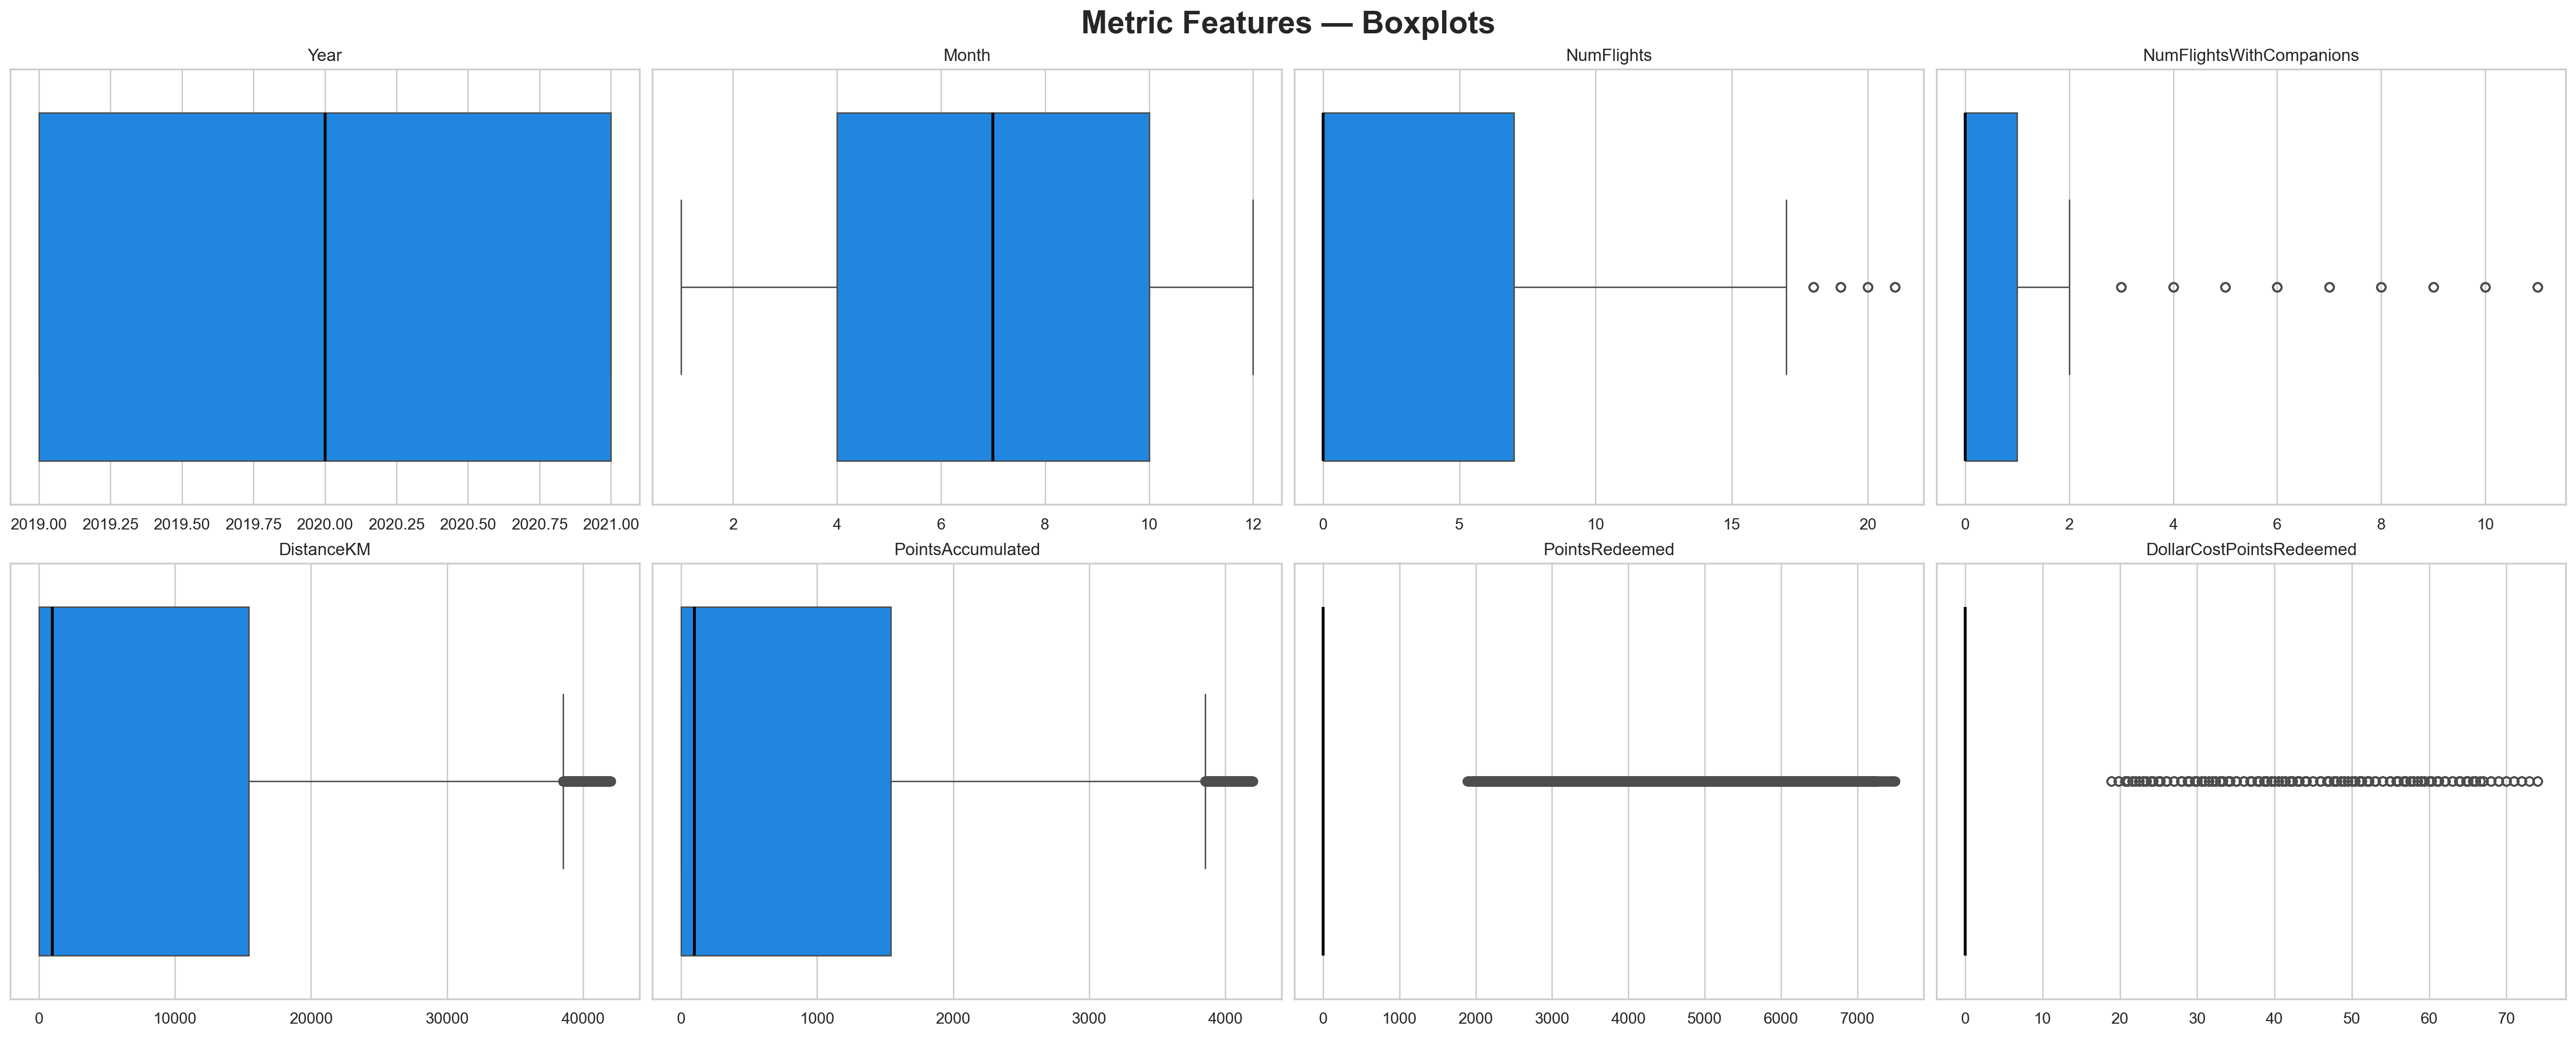

In [93]:
create_boxplots(flightsDB, n_cols=4, figsize=(25, 10))

In [94]:
# Create new binary columns indicating if points or dollars were redeemed
flightsDB["did_redeemed"] = np.where(flightsDB["PointsRedeemed"] > 0, 1, 0)
flightsDB["value_redeemed"] = np.where(flightsDB["DollarCostPointsRedeemed"] > 0, 1, 0)

# Cap extreme values with the maximum value 
max_distance = flightsDB["DistanceKM"].max()
flightsDB["DistanceKM"] = np.where(flightsDB["DistanceKM"] > max_distance, max_distance, flightsDB["DistanceKM"])

max_points_accumulated = flightsDB["PointsAccumulated"].max()
flightsDB["PointsAccumulated"] = np.where(flightsDB["PointsAccumulated"] > max_points_accumulated, max_points_accumulated, flightsDB["PointsAccumulated"])

<a class="anchor" id="5_4_2">

## **5.4.2.** Outliers Customer Dataset

[Back to TOC](#toc)
</a>

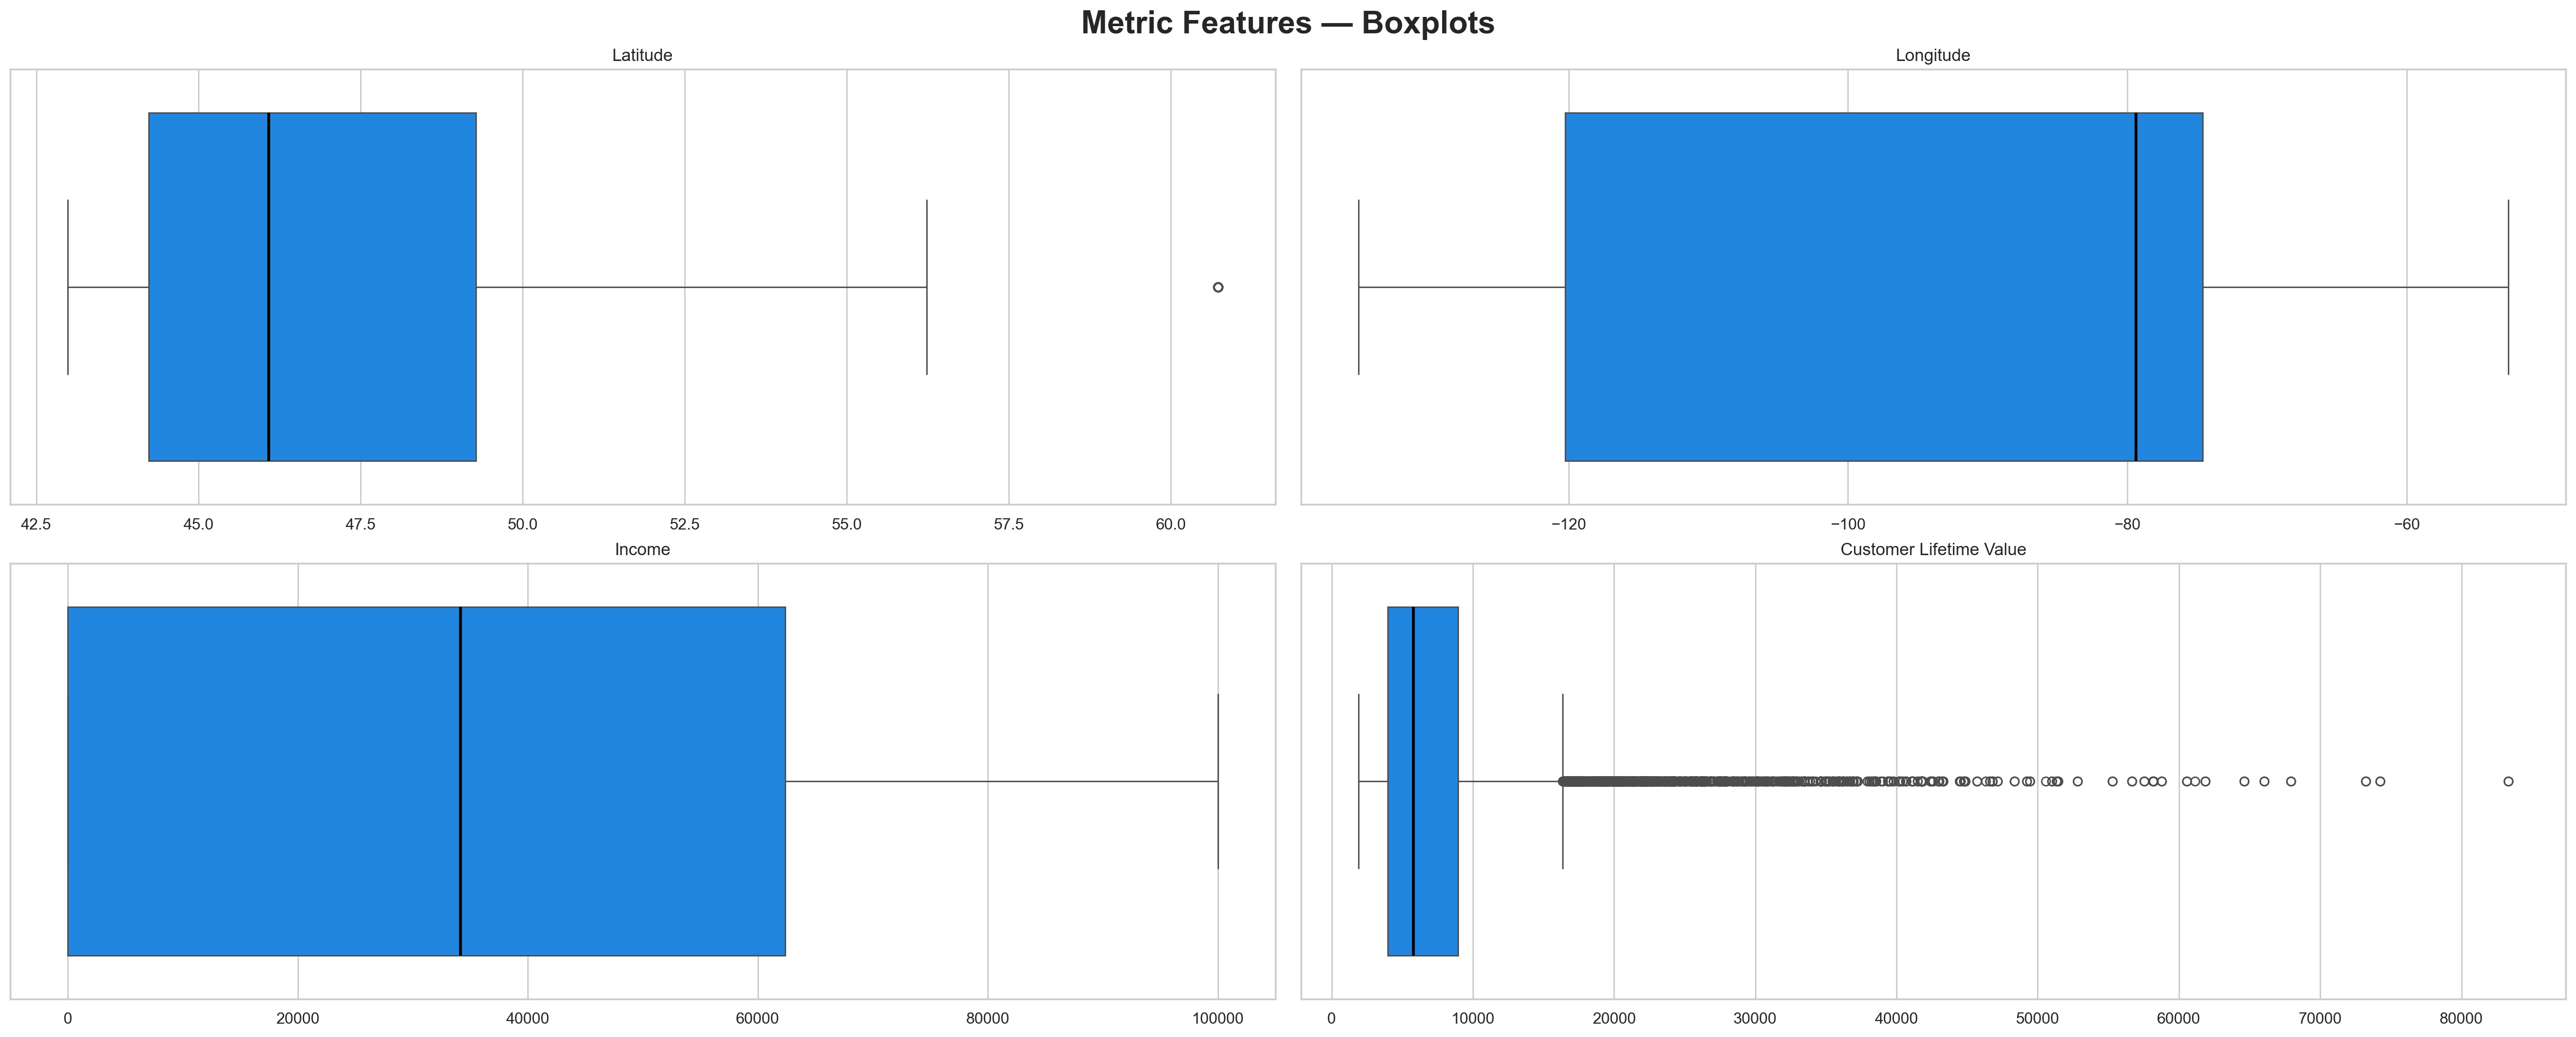

In [95]:
create_boxplots(customerDB, n_cols=2, figsize=(25, 10))

In this step, we decide to address the presence of outliers exclusively in the Customer Lifetime Value feature, as it is the only variable for which extreme values could substantially affect the clustering results.
To mitigate the impact of these outliers, we apply a logarithmic transformation and create a new engineered feature. This transformation reduces the skewness of the distribution, stabilizes variance, and facilitates a more meaningful clustering process.

The implementation of this treatment will be presented in the next section, Feature Engineering, where it conceptually fits within the workflow.

<a class="anchor" id="7">

# **7. Feature Engineering**

[Back to TOC](#toc)
</a>

Given that our project involves two datasets from the airline company—the flights dataset includes multiple records per customer reflecting their activity over time and the customer dataset only contains a single row per customer, we must ensure that the final dataset used for clustering is structured appropriately.

Clustering algorithms require each observation to represent a single entity; therefore, the final dataset must contain exactly one row per customer (one per Loyalty#), matching the structure of the customer dataset.

To achieve this, we will aggregate variables of the flights datset to create new features that summarize each customer's overall behavior. These aggregated features will then be merged with the customer dataset, ensuring that each customer is represented by a single, information, rich record suitable for clustering. 
This approach allows us to retain important behavioral patterns that would otherwise be lost.

In addition to the aggregated features derived from the flights dataset, we will also engineer new features directly from the customer dataset.
Overall, this feature engineering step is essential for integrating both datasets into a single, clean, and informative dataset for clustering.

<a class="anchor" id="7_1">

## **7.1** FlightsDB

[Back to TOC](#toc)
</a>

In [96]:
# Convert 'YearMonthDate' to datetime format 
flightsDB['YearMonthDate'] = pd.to_datetime(flightsDB['YearMonthDate'])

<a class="anchor" id="7_1_1">

### 7.1.1 Summary Features
[Back to TOC](#toc)
</a>

In [97]:
# CREATE SUMMARY FEATURES FOR FLIGHTSDB
# Aggregate by customer and rename in one step
flightsDB_fe = (
    flightsDB.groupby('Loyalty#', as_index=True)  # keep Loyalty# as index
    .agg(
        TotalFlights=('NumFlights', 'sum'),
        TotalFlightsWithCompanions=('NumFlightsWithCompanions', 'sum'),
        TotalDistanceKM=('DistanceKM', 'sum'),
        TotalPointsAccumulated=('PointsAccumulated', 'sum'),
        TotalPointsRedeemed=('PointsRedeemed', 'sum'),
        FlightsVariance=('NumFlights', 'var'),
        TotalMonthsActive=('YearMonthDate', 'nunique')
    )
)

<a class="anchor" id="7_1_2">

### 7.1.2 Recency
[Back to TOC](#toc)
</a>

In [98]:
last_flight = flightsDB[flightsDB['NumFlights'] != 0].groupby('Loyalty#')['YearMonthDate'].max().dt.year
last_year = 2021

flightsDB_fe['Recency'] = (last_year - last_flight) * 12 + (12 - flightsDB[flightsDB['NumFlights'] != 0].groupby('Loyalty#')['YearMonthDate'].max().dt.month)

<a class="anchor" id="7_1_2">

### 7.1.2 Points Redemption Ratio
[Back to TOC](#toc)
</a>

In [99]:
# PointsRedemptionRatio (Total)
# Avoid division by zero
flightsDB_fe['PointsRedemptionRatio'] = np.where(
    flightsDB_fe['TotalPointsAccumulated'] > 0,
    flightsDB_fe['TotalPointsRedeemed'] / flightsDB_fe['TotalPointsAccumulated'],
    0
)

<a class="anchor" id="7_1_3">

### 7.1.3 Average Flights Per Active Month
[Back to TOC](#toc)
</a>

In [100]:
# AvgFlightsPerActiveMonth
# Avoid division by zero
flightsDB_fe['AvgFlightsPerActiveMonth'] = np.where(
    flightsDB_fe['TotalMonthsActive'] > 0,
    flightsDB_fe['TotalFlights'] / flightsDB_fe['TotalMonthsActive'],
    0
)

<a class="anchor" id="7_1_4">

### 7.1.4 Total Flights With Companions Ratio
[Back to TOC](#toc)
</a>

In [101]:
# Total Flight With Companion Ratio (lifetime)
# Avoid division by zero
flightsDB_fe['TotalFlightWithCompanionRatio'] = np.where(
    flightsDB_fe['TotalFlights'] > 0,
    flightsDB_fe['TotalFlightsWithCompanions'] / flightsDB_fe['TotalFlights'],
    0
)

<a class="anchor" id="7_1_5">

### 7.1.5 Distance Per Flight
[Back to TOC](#toc)
</a>

In [102]:
# Total Distance per Flight
# Avoid division by zero
flightsDB_fe['DistancePerFlight'] = np.where(
    flightsDB_fe['TotalFlights'] > 0,
    flightsDB_fe['TotalDistanceKM'] / flightsDB_fe['TotalFlights'],
    0
)

<a class="anchor" id="7_1_6">

### 7.1.6 Average Distance Per Flight
[Back to TOC](#toc)
</a>

In [103]:
# Average Distance per Flight
# Avoid division by zero
flightsDB_fe['AvgDistancePerFlight'] = np.where(
    flightsDB_fe['TotalFlights'] > 0,
    flightsDB_fe['TotalDistanceKM'] / flightsDB_fe['TotalFlights'],
    0
)

<a class="anchor" id="7_1_7">

### 7.1.7 Preferred Season
[Back to TOC](#toc)
</a>

In [104]:
def season_from_month(m):
    if m in [12, 1, 2]: return 'Winter'
    if m in [3, 4, 5]:  return 'Spring'
    if m in [6, 7, 8]:  return 'Summer'
    return 'Autumn'

# Calculate preferred season per customer WITHOUT creating new columns in flightsDB
preferred_season = (
    flightsDB.groupby('Loyalty#')['Month']
             .agg(lambda x: season_from_month(x.mode().iloc[0]))
)

# Assign directly into flightsDB_fe
flightsDB_fe['PreferredSeason'] = flightsDB_fe.index.map(preferred_season)

<a class="anchor" id="7_2">

## **7.2.** CustomerDB

[Back to TOC](#toc)
</a>

In [105]:
# Convert enrollment dates to datetime
customerDB['EnrollmentDateOpening'] = pd.to_datetime(customerDB['EnrollmentDateOpening'])

# Create empty dataframe for customerDB features with the same index
customerDB_fe = pd.DataFrame(index=customerDB.index)

<a class="anchor" id="7_2_1">

### 7.2.1 IncomeBins
[Back to TOC](#toc)
</a>

In [106]:
# NÃO CRIAR ESTA FEATURE PQ É CATEGORICAL

# income = customerDB['Income']
# # create 4 quantile-based bins
# temp_bins = pd.qcut(income, q=4, duplicates='drop') # duplicates='drop' to avoid errors if there are not enough unique values
# # create labels based on the number of bins created 
# bins_labels = ['Very Low', 'Low', 'Medium', 'High'][:len(temp_bins.cat.categories)]
# customerDB_fe['IncomeBins'] = pd.qcut(
#     income,
#     q=4,
#     labels=bins_labels,
#     duplicates='drop' # to avoid errors if there are not enough unique values
# )

<a class="anchor" id="7_2_2">

### 7.2.2 HouseholdType
[Back to TOC](#toc)
</a>

In [107]:
# NÃO CRIAR ESTA FEATURE PQ É CATEGORICAL

# # HouseholdType → Marital + Location
# customerDB_fe['HouseholdType'] = (
#     customerDB['Location Code'] + '-' +
#     customerDB['Marital Status']
# )

<a class="anchor" id="7_2_4">

### 7.2.4 CLVBins
[Back to TOC](#toc)
</a>

In [108]:
# NÃO CRIAR ESTA FEATURE PQ É CATEGORICAL

# ## CLV BINS
# # Compute quartiles

# clv = customerDB['Customer Lifetime Value']
# temp_bins = pd.qcut(clv, q=5, duplicates='drop')
# clv_labels = ["Very Low", "Low", "Medium", "High", "Very High"][:len(temp_bins.cat.categories)]
# customerDB_fe['CLVBins'] = pd.qcut(
#     clv,
#     q=5,
#     labels=clv_labels,
#     duplicates='drop'
# )

<a class="anchor" id="7_2_5">

### 7.2.5 Log Costumer Lifetime Value
[Back to TOC](#toc)
</a>

In [109]:
# Create new feature with log transformation of CLV
customerDB_fe["log_CLV"] = np.log1p(customerDB["Customer Lifetime Value"]) 

<a class="anchor" id="7_2_6">

### 7.2.6 Is Active
[Back to TOC](#toc)
</a>

In [110]:
# IsActive
customerDB_fe['IsActive'] = (customerDB['CancellationDate'].eq("Active")).astype(int)

<a class="anchor" id="7_3">

## **7.3.** Feature Engineering with Both Datasets

[Back to TOC](#toc)
</a>

<a class="anchor" id="7_3_1">

## 7.3.1. Merge Datasets

[Back to TOC](#toc)
</a>

We begin this feature engineering subsection by joining the feature engineered datasets (customer_fe, flights_fe) and then merge this new dataset with the initial customer dataset . This step is necessary to combine information from both sources and to enable the creation of new features that leverage variables from each dataset.
The merge is performed using the customer dataset as the base since, as previously mentioned, our final dataset must contain exactly one row per customer ID to be suitable for clustering algorithms.

In [111]:
# Combine new features from customerDB and flightsDB
new_features = customerDB_fe.join(flightsDB_fe, how="left")
new_features

,log_CLV,IsActive,TotalFlights,TotalFlightsWithCompanions,TotalDistanceKM,TotalPointsAccumulated,TotalPointsRedeemed,FlightsVariance,TotalMonthsActive,Recency,PointsRedemptionRatio,AvgFlightsPerActiveMonth,TotalFlightWithCompanionRatio,DistancePerFlight,AvgDistancePerFlight,PreferredSeason
Loyalty#,,,,,,,,,,,,,,,,
480934,8.253264,1,184.0,53.0,507054.9,50699.39,13517.9,25.073016,36.0,0.0,0.266628,5.111111,0.288043,2755.733152,2755.733152,Winter
549612,8.253386,1,275.0,30.0,426827.4,42672.54,22457.8,29.608730,36.0,0.0,0.526282,7.638889,0.109091,1552.099636,1552.099636,Winter
429460,8.253423,0,116.0,37.0,238376.1,23832.41,5479.6,16.749206,36.0,11.0,0.229922,3.222222,0.318966,2054.966379,2054.966379,Winter
608370,8.253423,1,191.0,55.0,386029.3,38595.63,16331.5,22.161111,36.0,0.0,0.423144,5.305556,0.287958,2021.095812,2021.095812,Winter
530508,8.254214,1,167.0,59.0,369242.6,36916.56,0.0,28.980159,36.0,0.0,0.000000,4.638889,0.353293,2211.033533,2211.033533,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100012,8.662363,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100013,8.662363,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100014,8.662363,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We observed that some missing values appear in the new features created from the flights dataset. To investigate the cause, we compared, using the code shown below, the customer IDs present in both datasets and verified that some customers in the customer dataset do not appear in the flights dataset.
Since missing values were already handled earlier, we conclude that these cases correspond to customers who did not take any flights during the recorded period. 

Therefore, we replace the resulting NaN values with 0, indicating that these customers completed zero flights.
We note that this substitution is applied only to numeric columns, as it would not be meaningful for categorical variables and because the missing values in this context occur exclusively in numeric features.

In [112]:
set(customerDB_fe.index) - set(flightsDB_fe.index)

{100011,
 100012,
 100013,
 100014,
 100015,
 100016,
 100017,
 999987,
 999988,
 999989,
 999990,
 999991,
 999992,
 999993,
 999994,
 999995,
 999996,
 999997,
 999998,
 999999}

In [113]:
# Fill NaN values in new features with 0
numeric_cols = new_features.select_dtypes(include=[np.number]).columns
new_features[numeric_cols] = new_features[numeric_cols].fillna(0)

In [114]:
# Combine new features with original customerDB and assign it to final_dataset that will be used for clustering
final_dataset = customerDB.join(new_features, how="left")

<a class="anchor" id="7_3_2_2">

### 7.3.2.2 Redemption Rate By Loyalty Status
[Back to TOC](#toc)
</a>

In [115]:
# Redemption rate by loyalty status
loyalty_points_mean = final_dataset.groupby("LoyaltyStatus")["TotalPointsRedeemed"].transform("mean")
final_dataset["RedemptionRateByLoyaltyStatus"] = final_dataset["TotalPointsRedeemed"] / loyalty_points_mean

<a class="anchor" id="7_4">

## **7.4.** Summary of Engineered Features

[Back to TOC](#toc)
</a>

To summarise, we chose to keep:

FLIGHTSDB

- `TotalFlights`
- `TotalFlightsWithCompanions`
- `TotalDistanceKM`
- `TotalPointsAccumulated`
- `TotalPointsRedeemed`
- `FlightsVariance`
- `TotalMonthsActive`
- `Recency`
- `PointsRedemptionRatio`
- `AvgFlightsPerActiveMonth`
- `TotalFlightsWithCompanionsRatio`
- `DistancePerFlight`
- `AvgDistancePerFlight`
- `PreferredSeason`

CUSTOMERSDB

- `CLVvsCityMean`
- `log_CLV`
- `IsActive`


MERGED DATASETS

- `RedemptionRateByLoyaltyStatus`

<a class="anchor" id="8">

## **8. Scaling**

[Back to TOC](#toc)
</a>

In [116]:
final_dataset = scaling_features(final_dataset, 'standard')

<a class="anchor" id="9">

## **9. Feature Selectiom**

[Back to TOC](#toc)
</a>

We now move on to the feature selection stage, where we visualize a correlation heatmap to understand which features should be kept or removed.
From this heatmap, we can analyze the relationships between variables and identify features that are unlikely to contribute meaningfully to the model. Features with very low correlation to all others may be considered irrelevant, while those with very high correlation may introduce redundancy.
Based on this analysis, we will list the features that we decided to excluded and provide a justification for their removal.

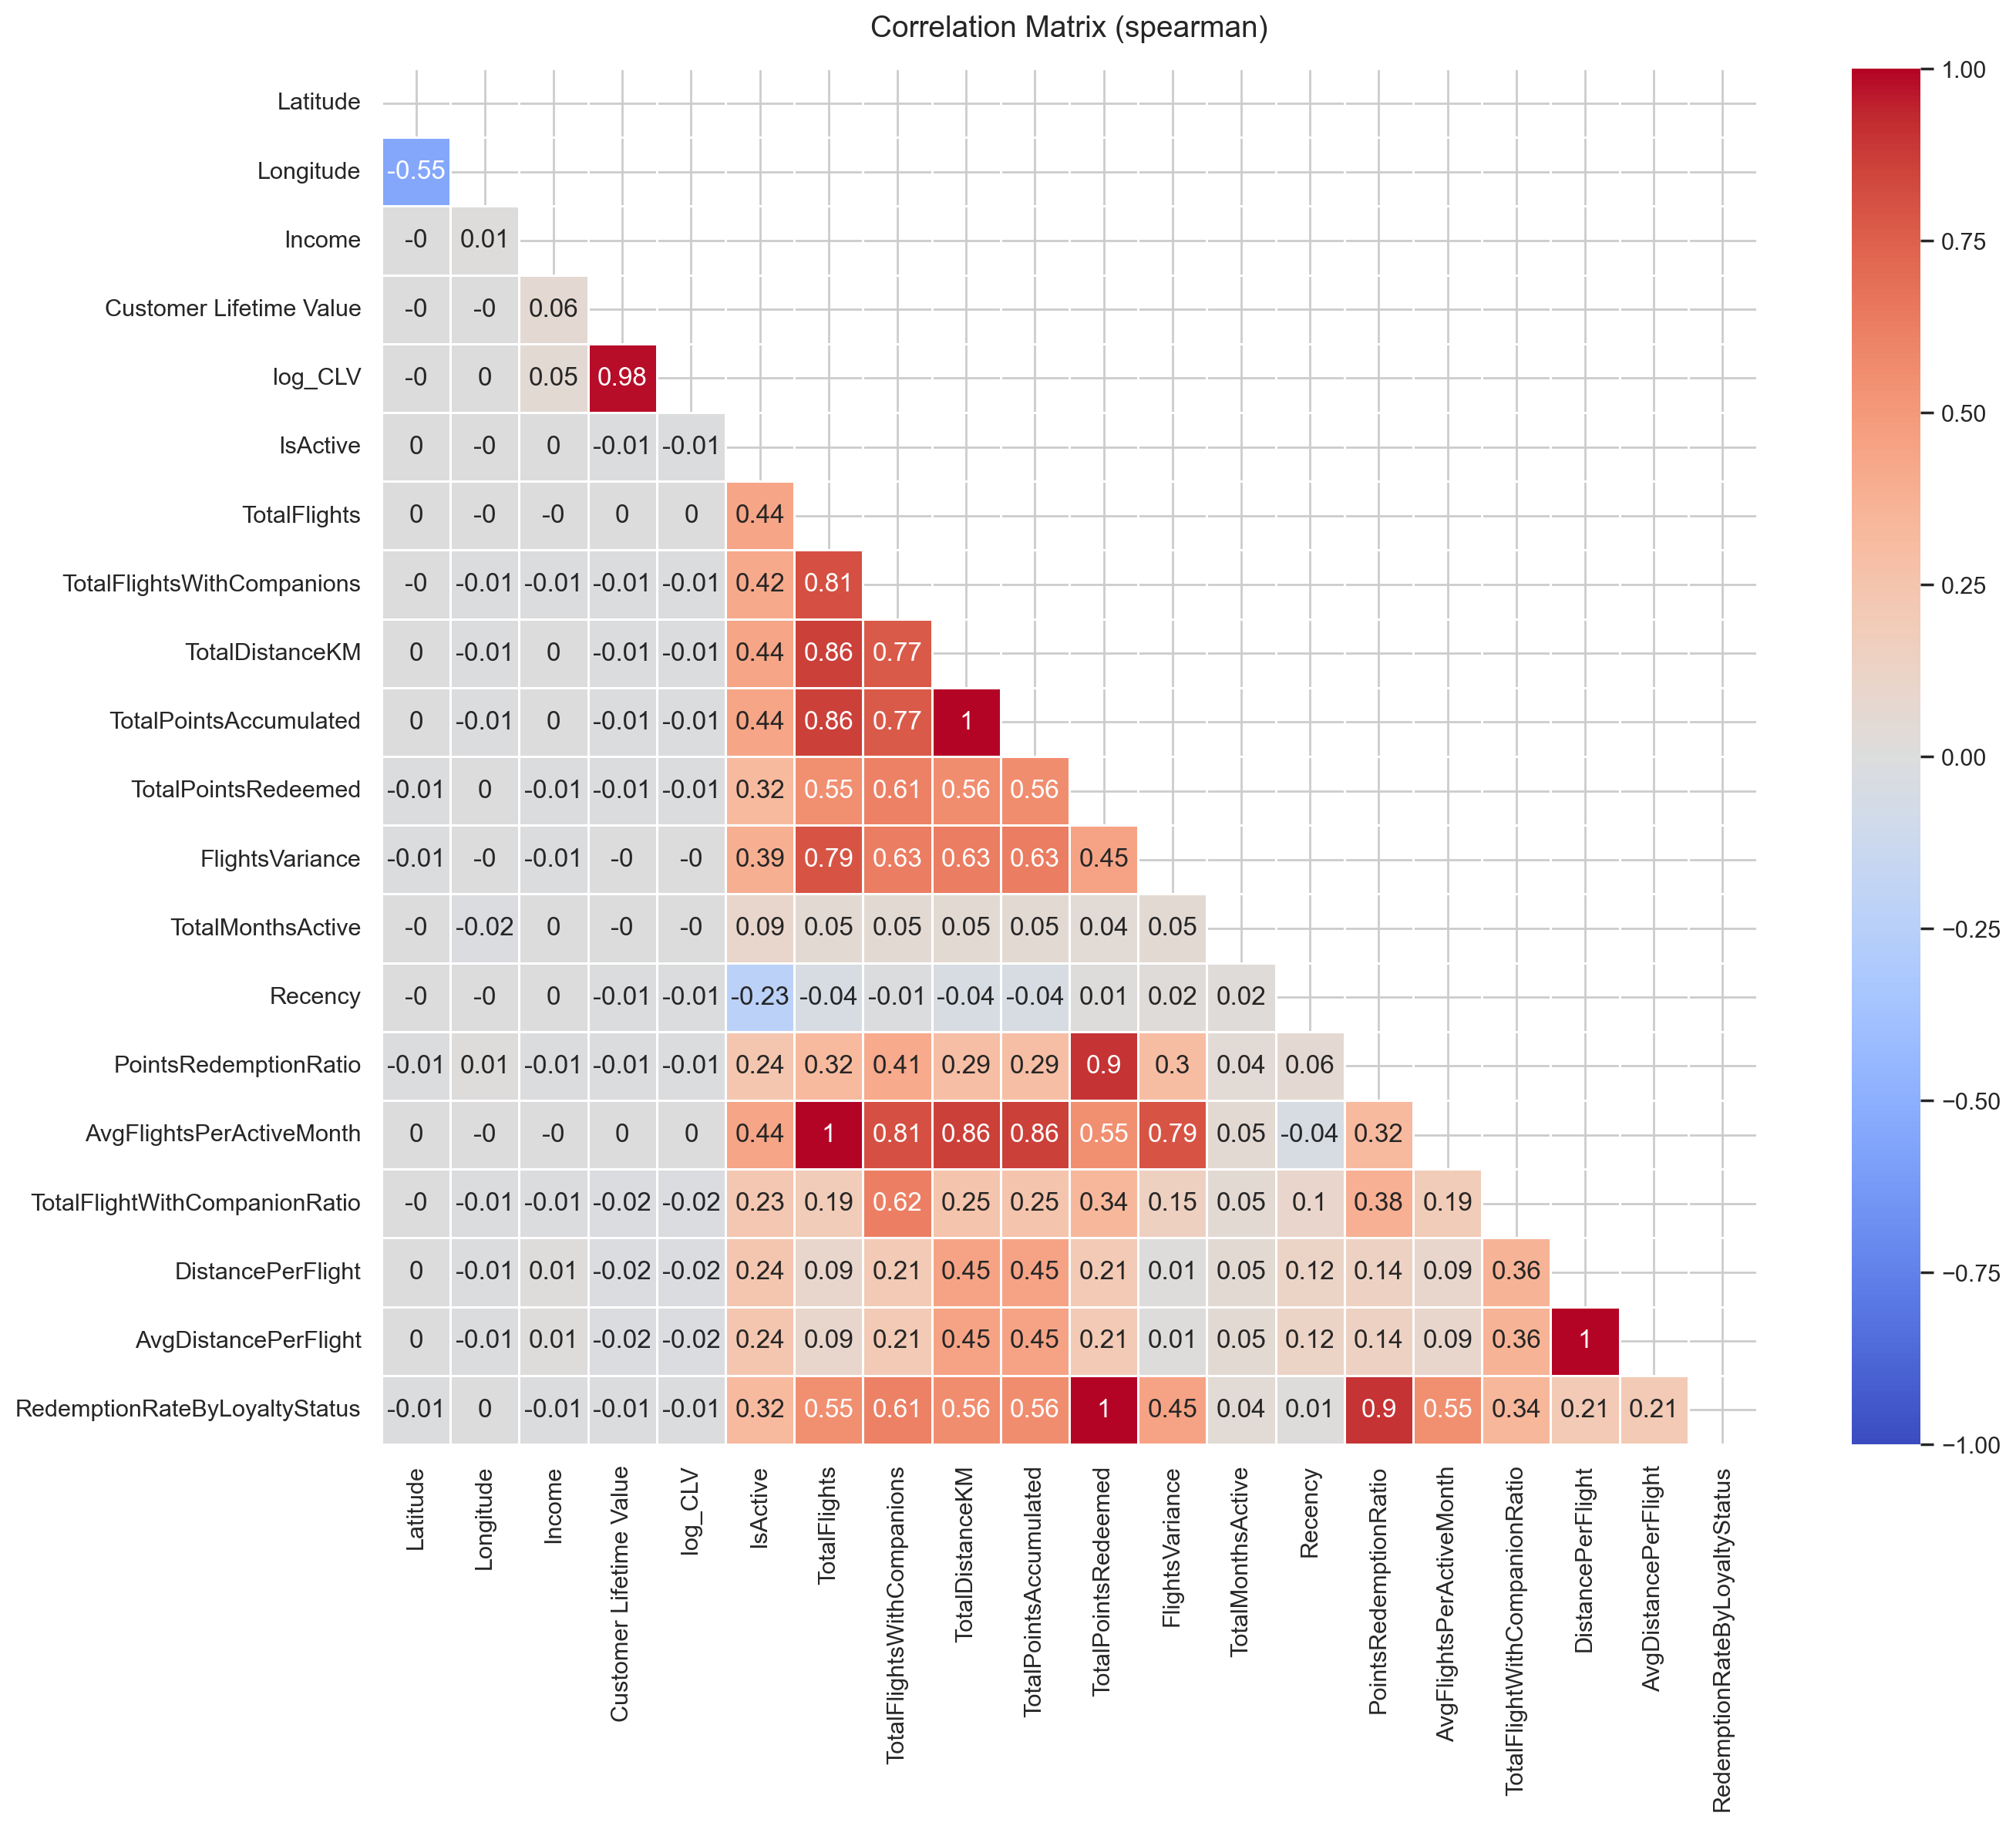

In [117]:
create_heatmap(final_dataset, method="spearman", figsize=(15, 12))

**Features to Remove:**

- `Latitude` and `Longitude:` This features do not show any meaningful correlation with other variables except between themselves, which is expected due to their geographical relationship. Since they don't contribute with useful information for our problem, they are removed.

- `Customer Lifetime Value:` Feature that exhibit extremely low correlation with all other features, with correlation values below 0.1. This indicates that it does not provide relevant information for the clustering process, so it's excluded.

-  `TotalPointsAccumulated: ` Similar to the previous case, this feature has a perfect correlation with TotalDistanceKM. To prevent duplication of information, we retain TotalDistanceKM and remove TotalPointsAccumulated.

-  `AvgFlightsPerActiveMonth: ` This feature has a perfect correlation (1.0) with TotalFlights. Since both variables convey the same information, we keep only TotalFlights to avoid redundancy.

-  `RedemptionRateByLoyaltyStatus: ` This feature has a perfect correlation with TotalPointsRedeemed, meaning they provide equivalent information. Therefore, we keep only one of them.

- `AvgDistancePerFlight: ` This feature has a perfect correlation with DistancePerFlight, so keeping both would be redundant. We retain only one of them.


In [118]:
#NOTAS: features que poderiam fazer sentido excluir mas que não foram excluídas pq tb podem dar informação talvez
# 
# - `Income:` This feature has a very low correlation with all other features (lower than 0.1). 
# Therefore, we decide to exclud it since it not provide relevant information for the rest of our process.

#`log_CLV - era excluida com o CLV mas decidi manter pq pode dar informação relevante

#-  `TotalMonthsActive: ` This feature shows very low correlation with most other variables. Its strongest relationship is with 
# IsActive, which we have already decided to keep. For this reason, TotalMonthsActive is removed.
# É uma das poucas features temporais que distingue: clientes novos, clientes antigos, clientes com baixa intensidade mas longa duração
# Usa muito pouco a variância → útil em clustering.

#-  `Recency: ` The rationale for removing Recency is similar to the previous one, as it also presents very 
# low correlations and does not add meaningful predictive value.
# Ela sozinho separa: clientes ativos, clientes em risco, clientes churned. É um dos pilares do RFM model (Recency-Frequency-Monetary).

In [119]:
features_to_drop = ['Latitude', 'Longitude', 'Customer Lifetime Value', 'TotalPointsAccumulated', 'AvgFlightsPerActiveMonth', 'RedemptionRateByLoyaltyStatus', 'AvgDistancePerFlight']

In [120]:
final_dataset.drop(columns=features_to_drop, inplace=True)

In [121]:
numeric_cols = final_dataset.select_dtypes(include=[np.number]).columns.tolist()
len(numeric_cols)

13

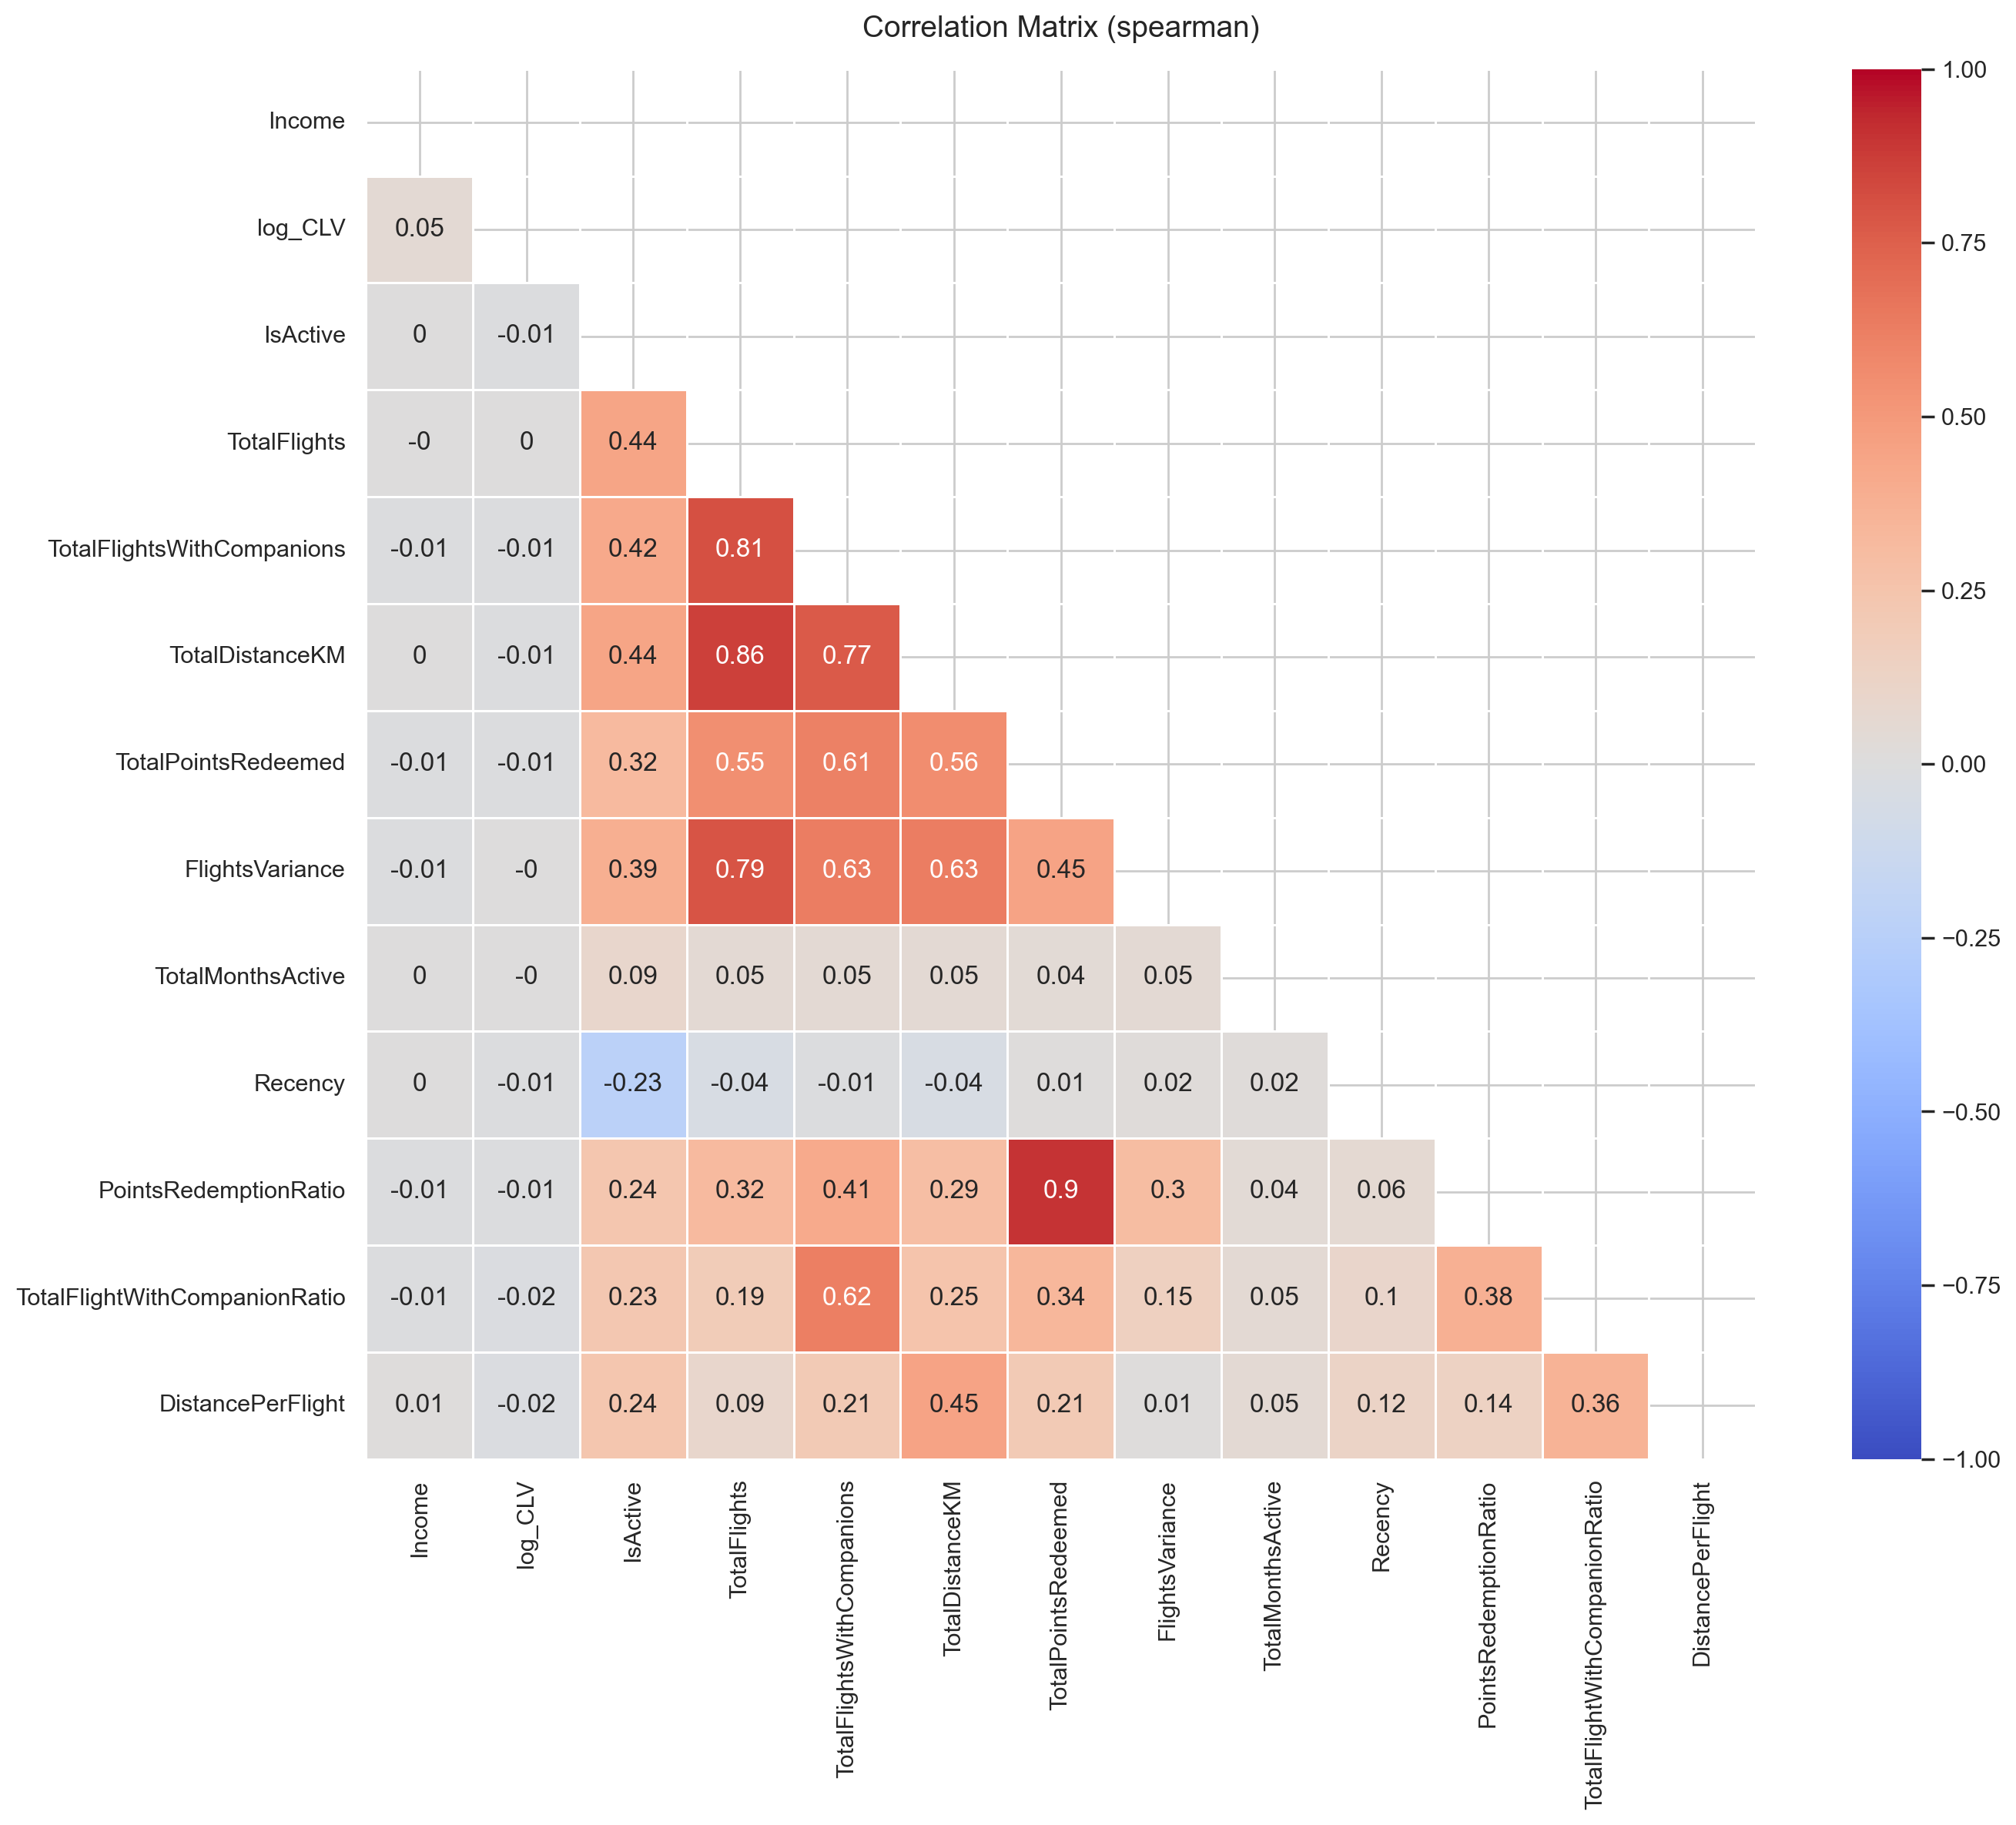

In [122]:
create_heatmap(final_dataset, method="spearman", figsize=(15, 12))